In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv("../data/raw/fut_prices_raw.csv", parse_dates= ["date"])
df.head()

,player_id,player_name,date,price
0,39,lionel-messi,2023-09-21,661957
1,39,lionel-messi,2023-09-22,159944
2,39,lionel-messi,2023-09-23,172778
3,39,lionel-messi,2023-09-24,215429
4,39,lionel-messi,2023-09-25,262156


In [41]:
#check the shape of the data
df.shape

(3982, 4)

In [42]:
#check for missing value
df.isna().sum()

player_id      0
player_name    0
date           0
price          0
dtype: int64

In [43]:
#check for dupicates
df.duplicated().sum()

np.int64(0)

In [44]:
df.describe()

,player_id,date,price
count,3982.000000,3982,3.982000e+03
mean,156.454545,2024-03-20 00:15:54.696132352,4.921734e+04
min,39.000000,2023-09-21 00:00:00,0.000000e+00
25%,50.000000,2023-12-20 00:00:00,7.917750e+03
50%,150.000000,2024-03-20 12:00:00,1.805250e+04
75%,243.000000,2024-06-19 00:00:00,3.303100e+04
max,320.000000,2024-09-17 00:00:00,1.705882e+06
std,105.127307,NaN,1.192314e+05


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3982 entries, 0 to 3981
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   player_id    3982 non-null   int64         
 1   player_name  3982 non-null   object        
 2   date         3982 non-null   datetime64[ns]
 3   price        3982 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 124.6+ KB


(0.0, 1800000.0)

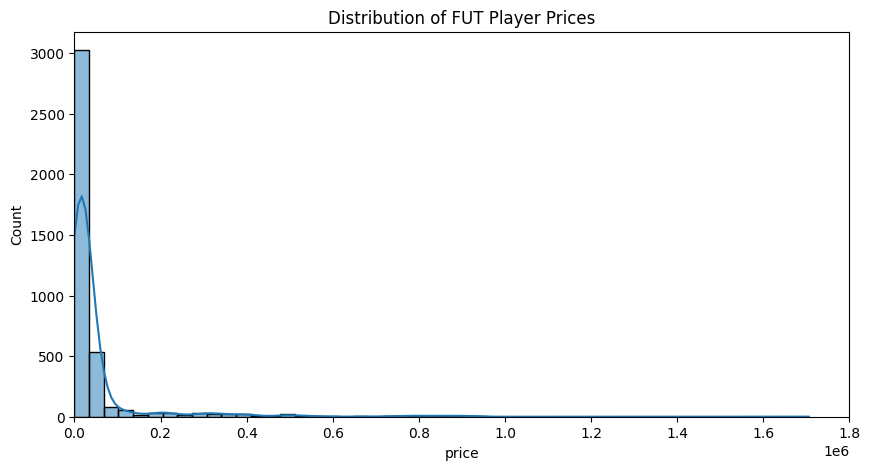

In [46]:
#Price distribution
plt.figure(figsize=(10,5))
sns.histplot(data= df, x= "price", bins= 50, kde=True)
plt.title("Distribution of FUT Player Prices")
plt.xlim((0, 1_800_000))

From the distribution above, we can see that the data is skewed to the right. Most of the players have a price between 0 and 160,000. This is normal as the players that got scraped were restricted to a certain level (gold players). 

Then, there are some really expensive players with a price ranging from 400,000 to 1.7 million. These are probably more popular players like Cristiano Ronaldo or Lionel Messi, as more people know them, their demand goes up which causes higher prices. 

However, we see that there are some players with a price of zero. This is impossible as you can't sell/buy a player in the game for free. Therefore, a value of zero most likely means that the data is missing so we will take care of that in the data cleaning.

Text(0.5, 1.0, 'Price History — Lionel Messi')

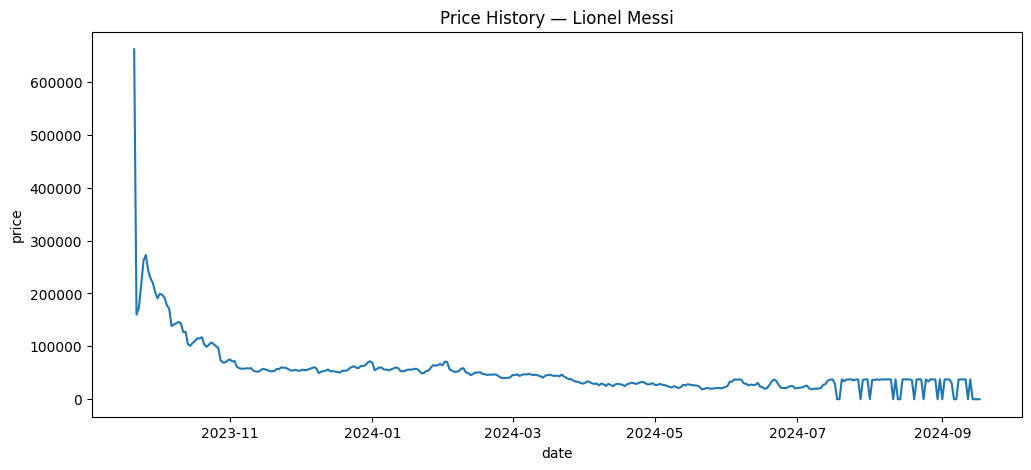

In [47]:
plt.figure(figsize=(12,5))
sns.lineplot(data=df[df["player_name"] == "lionel-messi"], x="date", y="price")
plt.title("Price History — Lionel Messi")

This chart of the price history of Lionel Messi tells us a lot. First of all, there was a big hype at the beginning and a lot of demand for that player. As there are only gold cards at the beginning of the game and that Lionel Messi is considered one of the best players in the world (highly rated player), it makes sense that his price is really high at the beginning. 

However, we can see a huge drop in the price a few days after the release of the game. This is probably due to substitute being discovered by users (for example, new player cards are released, users do not like the feeling of using that player, cheaper alternatives, etc.) as time passes.

As months passes, the price keeps going down. Since new player cards, special player cards, or new versions of Lionel Messi's card with better ratings are being released, it is normal that the price drops over time.

Lastly, we can see some small bumps approaching the end of the year. Since Lionel Messi has one of the highest rated card, his demand probably went up from time to time to use it for trades or challenges the game offers.

In [48]:

import plotly.express as px
px.line(df, x="date", y="price", color="player_name", title="Price Comparison Across Players")

The main insight that we get from these graphs is the different decay speed based on each player. In fact, some players are more durable than others. What do we mean by durable is that some are still better than alternatives that are being released or they just feel better to use for users during games. This phenomenon is also called a player being "meta". The "meta" is established by competitive players, streamers, and, in general, the community analyzing which players, or tactics yield the highest success rate.

In [49]:
df["pct_change"] = df.groupby("player_id")["price"].pct_change()
df[df["pct_change"].abs() > 0.5].head()

,player_id,player_name,date,price,pct_change
1,39,lionel-messi,2023-09-22,159944,-0.758377
300,39,lionel-messi,2024-07-18,0,-1.000000
302,39,lionel-messi,2024-07-20,37500,inf
310,39,lionel-messi,2024-07-28,0,-1.000000
311,39,lionel-messi,2024-07-29,36583,inf


In [60]:
import plotly.express as px
px.box(df, x=df["date"].dt.day_name(), y="price", title="FUT Player Prices by Day of Week", color= df["date"].dt.day_name(), labels={'x': 'Day of Week'})


Text(0.5, 0, 'Month')

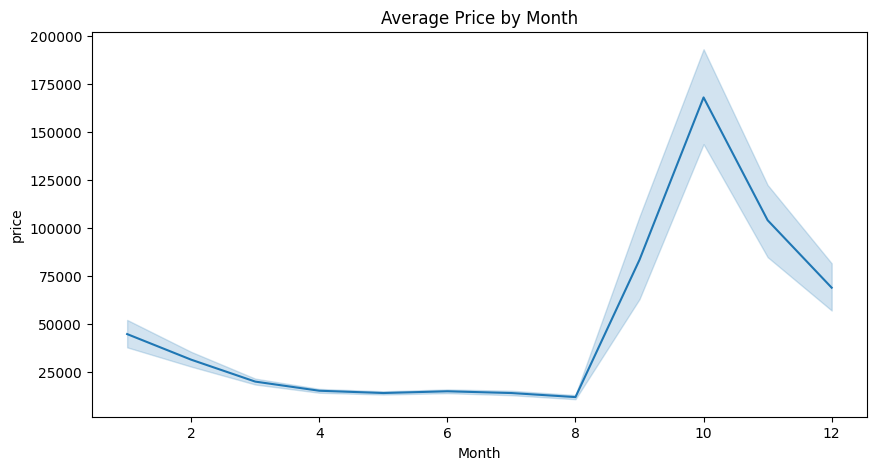

In [61]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x=df["date"].dt.month, y="price")
plt.title("Average Price by Month")
plt.xlabel("Month")

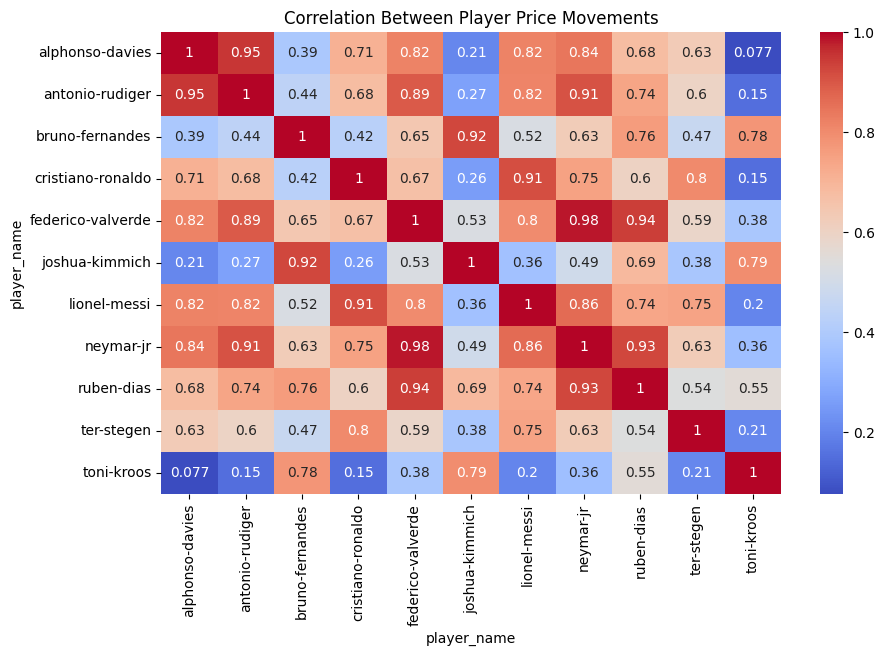

In [ ]:
pivot = df.pivot(index="date", columns="player_name", values="price")

plt.figure(figsize=(10,6))
sns.heatmap(pivot.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Player Price Movements")
plt.show()
